In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
emmarex_plantdisease_path = kagglehub.dataset_download('emmarex/plantdisease')

print('Data source import complete.')


Using Colab cache for faster access to the 'plantdisease' dataset.
Data source import complete.


In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/f63db177-4ffc-421f-b164-48f6a22dd14a___JR_HL 8169.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/e33a35bb-e830-470d-be7e-f21b136ab6bf___JR_HL 5894.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/b3025d7b-862b-4ec3-9724-982a12e305e5___JR_HL 7804.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/60006156-5cb7-4bae-ad51-8e4a3401e298___JR_HL 7848.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/9b92f829-7d58-4e53-99c6-b7f52eb51d59___JR_HL 8133.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/f33fb36e-18f9-4b55-a03c-c896e5c23186___JR_HL 5962.JPG
/kaggle/input/plantdisease/plantvillage/PlantVillage/Pepper__bell___healthy/674a896b-ff59-42df-8ffb-1f422c2084aa___JR_HL 8089.JPG
/kaggle/input/plantdisease/plantvillage

In [6]:
!pip install gradio opencv-python tensorflow matplotlib -q


In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

In [8]:
dataset_path = "/kaggle/input/plantdisease/PlantVillage"

# Check folders
print(os.listdir(dataset_path))

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [9]:

IMG_SIZE = 128

def preprocess_image(image_path):

    # Read image
    img = cv2.imread(image_path)

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize pixels
    img = img / 255.0

    return img

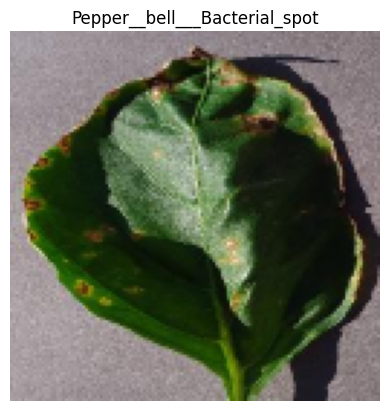

In [10]:
sample_class = os.listdir(dataset_path)[0]

sample_image = os.listdir(
    os.path.join(dataset_path, sample_class)
)[0]

sample_path = os.path.join(
    dataset_path,
    sample_class,
    sample_image
)

img = preprocess_image(sample_path)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [11]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='training'

)

val_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='validation'

)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [12]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(128,128,3)

)

# Freeze pretrained layers
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(
        train_generator.num_classes,
        activation='softmax'
    )

])

In [14]:

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(
        train_generator.num_classes,
        activation='softmax'
    )

])

In [16]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)


In [17]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=5

)


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 428s 816ms/step - accuracy: 0.7137 - loss: 0.8864 - val_accuracy: 0.8472 - val_loss: 0.4725
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 355s 686ms/step - accuracy: 0.8185 - loss: 0.5428 - val_accuracy: 0.8610 - val_loss: 0.4075
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 381s 684ms/step - accuracy: 0.8422 - loss: 0.4661 - val_accuracy: 0.8743 - val_loss: 0.3757
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 354s 685ms/step - accuracy: 0.8560 - loss: 0.4191 - val_accuracy: 0.8799 - val_loss: 0.3387
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 354s 685ms/step - accuracy: 0.8659 - loss: 0.3945 - val_accuracy: 0.8785 - val_loss: 0.3480


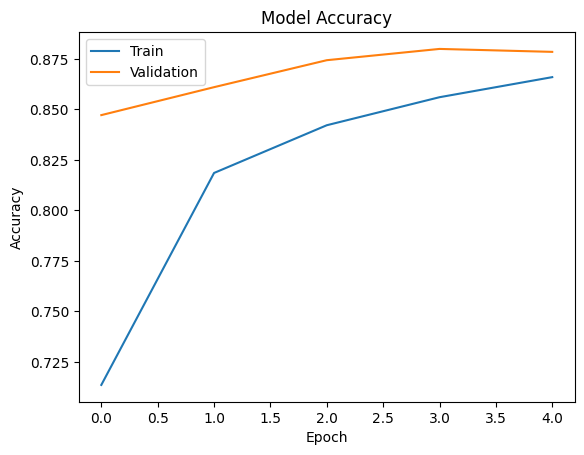

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [19]:
model.save("plant_disease_model.h5")


In [20]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [21]:
def predict_disease(image):

    # Resize image
    img = cv2.resize(image, (128,128))

    # Normalize
    img = img / 255.0

    # Expand dimensions
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction)

    return f"""
 Prediction: {predicted_class}

 Confidence: {confidence:.2f}
"""


In [22]:
interface = gr.Interface(

    fn=predict_disease,

    inputs=gr.Image(),

    outputs="text",

    title="🌱 Plant Disease Detector AI",

    description="Upload a plant leaf image"

)



interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://089b657b2f8d26798c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
